In [344]:
import torch

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    print(f"Total CUDA devices: {num_devices}")
    for i in range(num_devices):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No CUDA devices available.")


Total CUDA devices: 1
Device 0: NVIDIA RTX 2000 Ada Generation


In [345]:
# Set the default CUDA device to GPU 1 (3080)
torch.cuda.set_device(0)

# Example: creating a tensor on the selected device
device = torch.device("cuda")  # this now points to CUDA device 1

print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")


Using device: NVIDIA RTX 2000 Ada Generation


In [346]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
from neuralforecast.auto import NHITS
from neuralforecast.core import NeuralForecast
from neuralforecast.losses.pytorch import MSE
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures,LagFeatures
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sktime.transformations.series.fourier import FourierFeatures
from feature_engine.timeseries.forecasting import WindowFeatures
import holidays
import xgboost
from sklearn.ensemble import RandomForestRegressor
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
import csv
import lightgbm as lgb
from neuralforecast.models import NHITS, LSTM, TFT, TCN, TiDE, KAN


In [347]:
"""def sliding_window_forecast_fixed_size(modelname,fcst, DF_training_scaled, DF_validation_scaled, scaler_target, 
                                       prediction_horizon_steps=96, fixed_training_size=8832):

    # Create an empty DataFrame to store all predictions
    all_preds = pd.DataFrame()

    # Sliding window loop: run as long as there are enough validation points left
    num_iterations = len(DF_validation_scaled) // prediction_horizon_steps

    for i in range(num_iterations):
        # Step 1: Fit the model on the current training data (empty static features)
        fcst.fit(DF_training_scaled, static_features=[])

        # Step 2: Predict the next 'prediction_horizon_steps' (e.g., 96 steps)
        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))

        # Step 3: Reshape and inverse transform the predictions to original scale
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        # Step 4: Assign the predictions to the original DataFrame (store the time index 'ds' and unscaled predictions)
        preds[modelname+"_unscaled"] = predictions_original_scale

        # Step 5: Append predictions to the results DataFrame
        all_preds = pd.concat([all_preds, preds], axis=0)

        # Step 6: Update the training data by appending new validation data
        start_idx = i * prediction_horizon_steps
        end_idx = (i + 1) * prediction_horizon_steps
        new_data = DF_validation_scaled.iloc[start_idx:end_idx]

        # Remove the newly added data from DF_validation_scaled after each iteration
        #DF_validation_scaled = DF_validation_scaled.iloc[prediction_horizon_steps:]

        # Step 7: Maintain a fixed training size by appending new data and dropping the oldest data
        DF_training_scaled = pd.concat([DF_training_scaled, new_data], axis=0)
        if len(DF_training_scaled) > fixed_training_size:
            DF_training_scaled = DF_training_scaled.iloc[-fixed_training_size:]  # Keep only the latest entries

    return all_preds
    
"""

'def sliding_window_forecast_fixed_size(modelname,fcst, DF_training_scaled, DF_validation_scaled, scaler_target, \n                                       prediction_horizon_steps=96, fixed_training_size=8832):\n\n    # Create an empty DataFrame to store all predictions\n    all_preds = pd.DataFrame()\n\n    # Sliding window loop: run as long as there are enough validation points left\n    num_iterations = len(DF_validation_scaled) // prediction_horizon_steps\n\n    for i in range(num_iterations):\n        # Step 1: Fit the model on the current training data (empty static features)\n        fcst.fit(DF_training_scaled, static_features=[])\n\n        # Step 2: Predict the next \'prediction_horizon_steps\' (e.g., 96 steps)\n        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))\n\n        # Step 3: Reshape and inverse transform the predictions to original scale\n        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 

In [348]:
def sliding_window_forecast_fixed_size(modelname, fcst, DF_training_scaled, DF_validation_scaled, scaler_target, 
                                       prediction_horizon_steps=96, fixed_training_size=8832):
    """
    Perform a sliding window forecast with a fixed-size training set.
    
    Parameters:
    fcst (MLForecast): The forecast model.
    DF_training_scaled (pd.DataFrame): Scaled initial training data.
    DF_validation_scaled (pd.DataFrame): Scaled validation data for future predictions.
    scaler_target (MinMaxScaler): Scaler used to inverse transform the target variable.
    prediction_horizon_steps (int): Number of steps ahead to predict (default: 96).
    fixed_training_size (int): Fixed size of the rolling training window.
    
    Returns:
    pd.DataFrame: A DataFrame containing the day-ahead predictions for each step.
    """
    # Create an empty DataFrame to store all predictions
    all_preds = pd.DataFrame()

    # Sliding window loop: run as long as there are enough validation points left
    num_iterations = len(DF_validation_scaled) // prediction_horizon_steps

    for i in range(num_iterations):
        # Step 1: Fit the model on the current training data (empty static features)
        fcst.fit(DF_training_scaled, static_features=[])

        # Step 2: Predict the next 'prediction_horizon_steps' (e.g., 96 steps)
        # Ensure only the next prediction_horizon_steps rows are passed to X_df
        X_df = DF_validation_scaled.drop(columns=["y"], axis=1).iloc[:prediction_horizon_steps]
        preds = fcst.predict(h=prediction_horizon_steps, X_df=X_df)

        # Step 3: Reshape and inverse transform the predictions to original scale
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        # Step 4: Assign the predictions to the original DataFrame (store the time index 'ds' and unscaled predictions)
        preds[modelname+"_unscaled"] = predictions_original_scale

        # Step 5: Append predictions to the results DataFrame
        all_preds = pd.concat([all_preds, preds], axis=0)

        # Step 6: Update the training data by appending new validation data
        new_data = DF_validation_scaled.iloc[:prediction_horizon_steps]

        # Remove the newly added data from DF_validation_scaled after each iteration
        DF_validation_scaled = DF_validation_scaled.iloc[prediction_horizon_steps:]

        # Step 7: Maintain a fixed training size by appending new data and dropping the oldest data
        DF_training_scaled = pd.concat([DF_training_scaled, new_data], axis=0)
        if len(DF_training_scaled) > fixed_training_size:
            DF_training_scaled = DF_training_scaled.iloc[-fixed_training_size:]  # Keep only the latest entries

    return all_preds


In [349]:
def plot_predictions(model_name, df_validation_y, all_preds_unscaled):
    plt.figure(figsize=(14, 7))
    
    # Plot actual values
    plt.plot(df_validation_y.index, df_validation_y.values, label='Actual Values', color='blue', linewidth=2)
    
    # Plot predicted values
    plt.plot(all_preds_unscaled.index, all_preds_unscaled.values, label=f'Predicted Values ({model_name})', color='red', linestyle='-', linewidth=2)
    
    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Net Load')
    plt.title(f'Actual vs Predicted Values ({model_name})')
    
    # Add legend
    plt.legend()
    
    # Rotate x-ticks for better readability
    plt.xticks(rotation=45)
    
    # Show the plot
    plt.tight_layout()
    plt.show()



In [350]:
def CreateWorkHourFeature(input_data):
    """
    Receives as input a DataFrame or Series and outputs a DataFrame with the working hours during the day.
    When the day of the week is larger than 4, it is considered a weekend (1), otherwise, it's a workday (0).
    During workdays and between 8:00 and 17:00, it is considered a working hour.

    Parameters:
    input_data (DataFrame or Series): Input data with a DatetimeIndex.

    Returns:
    DataFrame: DataFrame with the added "WorkingHour_flag" column.
    """
    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    assert isinstance(input_df.index, pd.DatetimeIndex), "Index must be a datetime index."

    input_df["dayOfWeek"] = input_df.index.dayofweek
    input_df.loc[input_df["dayOfWeek"] > 4, "weekendFlag"] = 1
    input_df.loc[input_df["dayOfWeek"] < 5, "weekendFlag"] = 0
    input_df["hour"] = input_df.index.hour
    input_df["WorkingHour_flag"] = 0
    input_df.loc[((input_df["hour"] > 8) & (input_df["hour"] < 17) & (input_df["weekendFlag"] == 0)), "WorkingHour_flag"] = 1
    input_df.drop(["hour", "dayOfWeek", "weekendFlag"], axis=1, inplace=True)

    return input_df


def ListCreatorFlagger(df, substrings=['flag', 'cos', 'sin','day_of_week', 'day_of_month', 'weekend', 'days_in_month', 'hour', 'minute']):
    """
    A function that separates the columns containing specified substrings from those that don't.
    df is the dataframe in question and the substring is a list.
    """
    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return None, None

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns


def HolidayFeatureCreator(input_data):
    """
    Receives as input a DataFrame or Series and creates a column named "Holidays_flag" with 1 if there is a holiday and with 0 if no holidays exist.
    Holidays derived from Germany.
    """
    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    assert isinstance(input_df.index, pd.DatetimeIndex), "Index must be a datetime index."

    national_holidays_all = holidays.DE(years=[2014,2015,2016,2017,2018,2019,2020, 2021, 2022, 2023, 2024, 2025, 2026]).items()
    national_holidays = [items[0] for items in national_holidays_all]  # this is a list
    
    # Create a new column for holidays flag
    input_df["Holidays_flag"] = 0
    
    # Iterate over the index and set holiday flag to 1 if the date matches any national holiday
    for index_date in input_df.index:
        if index_date.date() in national_holidays:
            input_df.at[index_date, "Holidays_flag"] = 1
    
    return input_df




def TimeRelatedFeatureConstructor(df):
  """
  Works only in a dataframe as input: run the other functions first.
  Extracts time-related features
  """
  TimeFeaturesToExtract=["day_of_week","weekend","hour","minute",] #consider to add more
  dtfs=DatetimeFeatures(variables="index", features_to_extract=TimeFeaturesToExtract, drop_original=False)
  df=dtfs.fit_transform(df)

  CyclicalFeaturesToExtract=["day_of_week","hour","minute",]
  cyclical_dtfs=CyclicalFeatures(variables=CyclicalFeaturesToExtract,drop_original=False)
  df=cyclical_dtfs.fit_transform(df)
  return df


def FourierFeatureConstructor(df,granularity,fourier_terms_list):
    
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part)
    minutes4hour=60/number_int
    
    Fourier_Transformer=FourierFeatures(
        sp_list=[minutes4hour, 24*minutes4hour,24*7*minutes4hour,24*30*minutes4hour],   # hourly, 24 is daily seasonality *12 because for 60 min we have 12 intervals,  and 24*7 is weekly seasonality
        fourier_terms_list=fourier_terms_list,
        freq=granularity, #not necessery
        keep_original_columns=True,

    )

    Fourier_Transformer.fit(df)
    df=Fourier_Transformer.transform(df)
    return df

def WindowFeaturesConstructor(df, granularity, ListWithNoFlags):
    """
    This is a function that makes a list of 4 window features starting from double the granularity and following by doubling the previous value
    """
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part)
    double_granularity = 2 * number_int
    time_intervals = [double_granularity]
    
    # Calculate subsequent values
    for i in range(3):
        time_intervals.append(time_intervals[-1] * 2)
    
    windowlist = [interval // number_int for interval in time_intervals]  # Corrected division
    functionsList = ["mean", "std"]
    WindownFeatureTransformer = WindowFeatures(variables=ListWithNoFlags,
                                               functions=functionsList,
                                               window=windowlist,
                                               freq=granularity,
                                               drop_original=False)

    df = WindownFeatureTransformer.fit_transform(df)
    return df

def ExpandingWindowFeatureConstructor(df,ListWithNoFlags):
  functionsList=["mean","std"]
  frequency = pd.infer_freq(df.index) #infer the frequency from the dataframe
  ExpandingWindownFeatureTransformer=ExpandingWindowFeatures(variables=ListWithNoFlags,
                                                           functions=functionsList,
                                                           freq=frequency, #I put the freq to shift it down! but now it is performed automatically!
                                                           drop_original=False)
  df=ExpandingWindownFeatureTransformer.fit_transform(df)
  return df

def WeightedLinearFeatureMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that takes the original DF and modifies the continious value columns
  Inputs: Dataframe, List of columns that are continous values, daily window to slide, weights of the values
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window
  weights=np.arange(1,Window+1)

  # if i had hourly data then i would have had np.arange(1,24*7) for a weekly window

  def weighted_mean (x,weights):
    return (weights*x).sum()/weights.sum()

  def weighted_std(x,weights):
    mean_w= weighted_mean(x, weights)
    var_w= (weights* (x-mean_w)**2).sum()/weights.sum()
    return np.sqrt(var_w)

  # LETS make the weighted mean column
  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_mean, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_mean"]
    df=df.join(result)

  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_std, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_std"]
    df=df.join(result)
  return df

def ExpWeightMeanMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that makes exp weighted average with a sliding window approach
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window
  
  def exp_weights(alpha,window_size):
    """
    a function to calculate the weights for every single component of our sliding windown
    """
    weights=np.ones(window_size) #initializing weights
    for ix in range(window_size):
      weights[ix]=(1-alpha)**(window_size-1-ix)
    return weights

  def exp_weighted_mean(x):
    """
    a functions that calculates the exp weigted mean
    """

    weights=exp_weights(alpha=0.05, window_size=len(x)) # HERE WE SET THE ALPHA
    return (weights*x).sum()/weights.sum()
  
  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=int(Window))
        .agg([exp_weighted_mean])
        .shift(1)
    )


    result.columns=[str(i)+"_Exp_weighted_"+str(Window)+"_SL.win"]
    df=df.join(result)
  return df

def WeightedExponentialExpandingWindow(df,ListWithNoFlags,alpha):
  """
  This is a funtion that takes as input the df,a list of continuous values and the alpha.
  Outputs: all continuous features on the df that are "mean" and "std"
  """

  for i in ListWithNoFlags:
    df[[str(i)+"_ewm_mean_expanding.win",str(i)+"ewm_std_expanding.win"]]= (
                                              df[i].ewm(alpha=alpha).
                                              agg(["mean","std"])
                                              .shift(1)
                                            )
  return df

def FeatureLagger(df,ListOfFeatures,granularity,PredictionHorizon):

    time_intervals = []
    number_part = ''.join(filter(str.isdigit, granularity))
    Minutedensity=int(number_part)
    end_in_day=int((PredictionHorizon)/(Minutedensity))
    for i in range(1, 1+end_in_day):  # 24 hours * 60 minutes / 15 minutes = 96 intervals
        time_intervals.append(f"{i * 15}min")

    lag_transformer= LagFeatures(variables=ListOfFeatures,
                                freq=time_intervals,
                                drop_original=False) #make a lagger transformer drop all original features

    df=lag_transformer.fit_transform(df) # transform the features to DF joined
    return df

In [351]:
def ErrorCalculator(name, y_true, y_pred):
    errors = {"Pipelines": name,
              "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
              "MAE": mean_absolute_error(y_true, y_pred),
              "MSE": mean_squared_error(y_true, y_pred),
              
              "PMAE": peak_MAE(y_true, y_pred),
              "PMSE": peak_MSE(y_true, y_pred),
              "PRMSE": peak_RMSE(y_true, y_pred),
              
              "VMAE": valley_MAE(y_true, y_pred),
              "VMSE": valley_MSE(y_true, y_pred),
              "VRMSE": valley_RMSE(y_true, y_pred),
              
              "xMAE": extreme_MAE(y_true, y_pred),
              "xMSE": extreme_MSE(y_true, y_pred),
              "xRMSE": extreme_RMSE(y_true, y_pred),
             }
    return errors

def peak_MAE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mse

def peak_MSE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def peak_RMSE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse

def valley_MAE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mse

def valley_MSE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def valley_RMSE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse
def extreme_MAE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Absolute Error (MAE) for the filtered data
    mae = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mae

def extreme_MSE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def extreme_RMSE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Root Mean Squared Error (RMSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse


In [352]:
def separate_future_past_features(df_columns):
    """
    Separates future and past features from a list of dataframe columns.

    Args:
        df_columns (list): A list of column names from the dataframe.

    Returns:
        dict: A dictionary with keys 'future_features' and 'past_features', containing the respective lists of column names.
    """
    future_keywords = ['sin', 'cos', 'weekend', 'hour', 'holiday', 'minute', 'day','+']
    
    future_features = []
    past_features = []
    
    for col in df_columns:
        # Check if the column contains "+" in its name to classify as a past feature
        if any(keyword in col.lower() for keyword in future_keywords):
            future_features.append(col)
        # Columns that don't meet the above conditions are considered past features by default
        else:
            past_features.append(col)

    return future_features, past_features

In [353]:
#example https://nixtlaverse.nixtla.io/neuralforecast/docs/capabilities/exogenous_variables.html

In [354]:
df = pd.read_csv(r"C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\inputs\Clean_NISThomeAllfeatures.csv",index_col=0, parse_dates=[0])

#all dataframes should have these columns ['unique_id', 'ds', 'y']
# in this case the y is the price and the rest are covariates

# setting up the scenario parameters

In [355]:
#Calculate NetLoad!
OriginalFeatures=["NetLoad"]
scenario="1"
season="winter" #for winter it works!
OutputPath = r"C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\outputs"

granularity="15min"
prediction_horizon="1440min"

number_part_hor = ''.join(filter(str.isdigit, prediction_horizon))
PredictionHorizon=int(number_part_hor)
number_part = ''.join(filter(str.isdigit, granularity))
Minutedensity=int(number_part)
fourier_terms_list=[2,2,2,2]
prediction_horizon_steps=PredictionHorizon//Minutedensity # this is 96

In [356]:

if season=="summer":
    #df = df[df.index.month.isin([5, 6, 7, 8])]
    df = df[((df.index.month == 7) & (df.index.day <= 15)) |  # First half of July
        ((df.index.month == 3) & (df.index.day > 15)) |   # Last half of March
        (df.index.month.isin([4, 5, 6]))]                # April, May, June
elif season=="winter":
    df=df[df.index.month.isin([9, 10, 11, 12])]

#keep the features that are needed for each scenario
if scenario=="0":
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad"]]
    
if scenario=="1":
    #forecasting Net load only with features from the past
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad","T_out","Irradiance","Wind_speed"]]
    OriginalFeatures=["NetLoad","T_out","Irradiance","Wind_speed"]
    
if scenario=="2":
    #forecasting Net load with features from the past and future
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad","T_out","Irradiance","Wind_speed"]]
    
if scenario=="3":
    #forecasting household load and SolarPower with features from the past. Then combine them to get the NetLoad
    df=df[["Total_load","T_out","Irradiance","Wind_speed","SolarPower"]]
    
if scenario=="4":
    #forecasting household load with features from the past and future. Then combine them to get the NetLoad 
    df=df[["Total_load","T_out","Irradiance","Wind_speed","SolarPower"]]

In [357]:
df=HolidayFeatureCreator(df)
df=CreateWorkHourFeature(df)
df=TimeRelatedFeatureConstructor(df)
df=FourierFeatureConstructor(df,granularity,fourier_terms_list)
ListWithNoFlags,ListWithFlags=ListCreatorFlagger(df)
df=WindowFeaturesConstructor(df,granularity,ListWithNoFlags)
df=ExpandingWindowFeatureConstructor(df,ListWithNoFlags)
df=WeightedLinearFeatureMaker(df,ListWithNoFlags,granularity)
df=ExpWeightMeanMaker(df,ListWithNoFlags,granularity)
df=WeightedExponentialExpandingWindow(df,ListWithNoFlags,0.5)
df=FeatureLagger(df,OriginalFeatures,granularity,PredictionHorizon)
df["month"] = df.index.month
# =========================
# HOUR FEATURES (24-hour cycle)
# =========================
df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

# =========================
# MONTH FEATURES (12-month cycle)
# =========================
df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)


In [358]:
#make the target
df["NetLoad_+lag"+str(PredictionHorizon)]=df["NetLoad"].shift(int(-PredictionHorizon/Minutedensity))

target="NetLoad_+lag"+str(PredictionHorizon)
df.dropna(inplace=True)

In [359]:
import lightgbm as lgb
import pandas as pd

# =========================
# Prepare data
# =========================


DF_training = df.loc[
    "2015-09-02 00:00:00":"2015-12-02 23:45:00"
].copy()

X = DF_training.drop(columns=[target, "unique_id", "ds"], errors="ignore")
y = DF_training[target]

# =========================
# Train model
# =========================
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

# =========================
# Feature importance
# =========================
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.tail(20))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 118227
[LightGBM] [Info] Number of data points in the train set: 8832, number of used features: 481
[LightGBM] [Info] Start training from score -443.888050
                          feature  importance
162         Irradiance_lag_270min           6
15                     minute_cos           6
285              T_out_lag_735min           6
42            T_out_window_4_mean           6
377             T_out_lag_1080min           5
385             T_out_lag_1110min           5
253              T_out_lag_615min           5
257              T_out_lag_630min           5
5                WorkingHour_flag           5
305              T_out_lag_810min           5
4                   Holidays_flag           4
309              T_out_lag_825min           4
173              T_out_lag_315min           4
325      

In [360]:
print(importance_df["feature"].tolist())

['sin_2880.0_1', 'NetLoad', 'sin_672.0_1', 'T_out_expanding_mean', 'NetLoad_expanding_mean', 'Wind_speed_expanding_std', 'sin_672.0_2', 'cos_672.0_1', 'Wind_speed_expanding_mean', 'cos_2880.0_2', 'day_of_week_sin', 'T_out_expanding_std', 'T_out_weighted_96_std', 'NetLoad_lag_1440min', 'NetLoad_expanding_std', 'cos_672.0_2', 'sin_96.0_1', 'Wind_speed_weighted_96_std', 'NetLoad_lag_855min', 'day_of_week_cos', 'cos_2880.0_1', 'sin_2880.0_2', 'NetLoad_lag_1410min', 'T_out', 'cos_96.0_1', 'NetLoad_weighted_96_std', 'NetLoad_lag_15min', 'NetLoad_lag_1425min', 'day_of_week', 'T_out_window_16_std', 'Irradiance_weighted_96_std', 'NetLoadewm_std_expanding.win', 'Wind_speed_window_8_std', 'Wind_speed_window_4_std', 'Wind_speed_window_16_std', 'Wind_speedewm_std_expanding.win', 'NetLoad_lag_1395min', 'sin_96.0_2', 'NetLoad_lag_870min', 'Irradiance_window_2_std', 'NetLoad_lag_1260min', 'NetLoad_lag_525min', 'cos_96.0_2', 'Wind_speed_lag_1395min', 'T_out_window_4_std', 'NetLoad_window_16_std', 'hour

In [361]:
month_features = [f for f in importance_df["feature"] if "month" in f]

print(month_features)

['month', 'sin_month', 'cos_month']


In [362]:
df

,NetLoad,T_out,Irradiance,Wind_speed,Holidays_flag,WorkingHour_flag,day_of_week,weekend,hour,minute,...,NetLoad_lag_1440min,T_out_lag_1440min,Irradiance_lag_1440min,Wind_speed_lag_1440min,month,sin_hour,cos_hour,sin_month,cos_month,NetLoad_+lag1440
2015-09-02 00:00:00,682.028466,24.034213,0.000943,1.866667,0,0,2,0,0,0,...,321.361626,22.870824,0.000964,2.380000,9,0.000000,1.000000,-1.000000e+00,-1.836970e-16,639.833325
2015-09-02 00:15:00,1217.900351,24.057469,0.000952,1.113333,0,0,2,0,0,15,...,992.385435,22.748477,0.000942,2.626667,9,0.000000,1.000000,-1.000000e+00,-1.836970e-16,1129.955101
2015-09-02 00:30:00,989.671182,23.730711,0.000925,1.493333,0,0,2,0,0,30,...,374.223879,22.541770,0.000931,2.140000,9,0.000000,1.000000,-1.000000e+00,-1.836970e-16,863.181119
2015-09-02 00:45:00,705.263733,23.819097,0.000951,1.400000,0,0,2,0,0,45,...,861.487071,22.424297,0.000943,2.020000,9,0.000000,1.000000,-1.000000e+00,-1.836970e-16,637.028970
2015-09-02 01:00:00,1317.555024,23.795369,0.000971,1.120000,0,0,2,0,1,0,...,415.110060,22.272275,0.000947,1.873333,9,0.258819,0.965926,-1.000000e+00,-1.836970e-16,1086.092361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-30 22:45:00,1071.651811,9.778512,0.001053,0.940000,0,0,2,0,22,45,...,303.517265,7.741863,0.001037,1.520000,12,-0.500000,0.866025,-2.449294e-16,1.000000e+00,806.483673
2015-12-30 23:00:00,301.594653,9.175716,0.000966,0.980000,0,0,2,0,23,0,...,880.194111,7.212136,0.000905,0.980000,12,-0.258819,0.965926,-2.449294e-16,1.000000e+00,694.377304
2015-12-30 23:15:00,888.815384,9.883320,0.001008,0.726667,0,0,2,0,23,15,...,665.956032,7.694148,0.000961,0.906667,12,-0.258819,0.965926,-2.449294e-16,1.000000e+00,1141.953873
2015-12-30 23:30:00,577.278874,9.790636,0.001005,1.026667,0,0,2,0,23,30,...,763.352255,7.694132,0.000981,1.306667,12,-0.258819,0.965926,-2.449294e-16,1.000000e+00,1189.757622


In [363]:
newfs=['NetLoad_+lag1440','NetLoad',
 'T_out',
 'Irradiance',
 'Wind_speed',
 'hour',
 'minute_cos',
  'minute_sin',
  'Holidays_flag',
  'weekend',
 'day_of_week_cos',
 'day_of_week_sin',
 'sin_month',
 'cos_month',

 'sin_hour',
 'cos_hour',
 'T_out_lag_720min',
 'Irradiance_lag_720min',
 'Wind_speed_lag_720min',
 'T_out_lag_1440min',
 'Irradiance_lag_1440min',
 'Wind_speed_lag_1440min',

 'NetLoad_window_2_std',
 'T_out_window_2_mean',
 'T_out_window_2_std',
 'Irradiance_window_2_mean',
 'Irradiance_window_2_std',
 'Wind_speed_window_2_mean',
 'Wind_speed_window_2_std',
  'NetLoad_window_4_mean',
 'NetLoad_window_4_std',
 'T_out_window_4_mean',
 'T_out_window_4_std',
 'Irradiance_window_4_mean',
 'Irradiance_window_4_std',
 'Wind_speed_window_4_mean',
 'Wind_speed_window_4_std',
 ]

df=df[newfs]

In [364]:
"""newfs=['NetLoad_+lag1440','NetLoad',
 'T_out',
 'Irradiance',
 'Wind_speed',
 'hour',
 'minute',
 'dayofweek',
 'month',
 'sin_hour',
 'cos_hour',
 'NetLoad_window_2_mean',
 'NetLoad_window_2_std',
 'T_out_window_2_mean',
 'T_out_window_2_std',
 'Irradiance_window_2_mean',
 'Irradiance_window_2_std',
 'Wind_speed_window_2_mean',
 'Wind_speed_window_2_std',
  'NetLoad_window_4_mean',
 'NetLoad_window_4_std',
 'T_out_window_4_mean',
 'T_out_window_4_std',
 'Irradiance_window_4_mean',
 'Irradiance_window_4_std',
 'Wind_speed_window_4_mean',
 'Wind_speed_window_4_std',]"""

"""df=df[newfs]"""

'df=df[newfs]'

In [365]:
#there are no selected features since this is a simple baseline
features_after_FS1=df.columns.to_list()

In [366]:
features_after_FS1

['NetLoad_+lag1440',
 'NetLoad',
 'T_out',
 'Irradiance',
 'Wind_speed',
 'hour',
 'minute_cos',
 'minute_sin',
 'Holidays_flag',
 'weekend',
 'day_of_week_cos',
 'day_of_week_sin',
 'sin_month',
 'cos_month',
 'sin_hour',
 'cos_hour',
 'T_out_lag_720min',
 'Irradiance_lag_720min',
 'Wind_speed_lag_720min',
 'T_out_lag_1440min',
 'Irradiance_lag_1440min',
 'Wind_speed_lag_1440min',
 'NetLoad_window_2_std',
 'T_out_window_2_mean',
 'T_out_window_2_std',
 'Irradiance_window_2_mean',
 'Irradiance_window_2_std',
 'Wind_speed_window_2_mean',
 'Wind_speed_window_2_std',
 'NetLoad_window_4_mean',
 'NetLoad_window_4_std',
 'T_out_window_4_mean',
 'T_out_window_4_std',
 'Irradiance_window_4_mean',
 'Irradiance_window_4_std',
 'Wind_speed_window_4_mean',
 'Wind_speed_window_4_std']

In [367]:
df=df[features_after_FS1]
df["unique_id"]="sc"+scenario
df["ds"]=df.index
df = df.rename(columns={target: 'y'})


In [368]:
# Step 1: Determine the number of rows in the DataFrame
total_size = len(df)

# Step 2: Define the number of rows for validation and test sets
validation_test_size = 96*7*2

# =========================
# TRAIN
# =========================
DF_training = df.loc[
    "2015-09-02 00:00:00":"2015-12-02 23:45:00"
].copy()

# =========================
# VALIDATION
# =========================
DF_validation = df.loc[
    "2015-12-03 00:00:00":"2015-12-16 23:45:00"
].copy()

# =========================
# TEST
# =========================
DF_test = df.loc[
    "2015-12-17 00:00:00":"2015-12-30 23:45:00"
].copy()

# Step 4: Verify the sizes of each set
print("Training set size:", len(DF_training))
print("Validation set size:", len(DF_validation))
print("Test set size:", len(DF_test))



Training set size: 8832
Validation set size: 1344
Test set size: 1344


In [369]:
DF_training

,y,NetLoad,T_out,Irradiance,Wind_speed,hour,minute_cos,minute_sin,Holidays_flag,weekend,...,NetLoad_window_4_mean,NetLoad_window_4_std,T_out_window_4_mean,T_out_window_4_std,Irradiance_window_4_mean,Irradiance_window_4_std,Wind_speed_window_4_mean,Wind_speed_window_4_std,unique_id,ds
2015-09-02 00:00:00,639.833325,682.028466,24.034213,0.000943,1.866667,0,1.0,0.000000e+00,0,0,...,920.356780,209.820144,24.691501,0.311507,0.000951,0.000023,1.303333,0.229815,sc1,2015-09-02 00:00:00
2015-09-02 00:15:00,1129.955101,1217.900351,24.057469,0.000952,1.113333,0,-0.5,8.660254e-01,0,0,...,840.939186,229.019710,24.464530,0.389134,0.000946,0.000021,1.458333,0.354249,sc1,2015-09-02 00:15:00
2015-09-02 00:30:00,863.181119,989.671182,23.730711,0.000925,1.493333,0,-0.5,-8.660254e-01,0,0,...,987.935784,236.985342,24.266863,0.324824,0.000952,0.000017,1.436667,0.377222,sc1,2015-09-02 00:30:00
2015-09-02 00:45:00,637.028970,705.263733,23.819097,0.000951,1.400000,0,1.0,-2.449294e-16,0,0,...,954.420504,220.269061,24.016114,0.211774,0.000939,0.000011,1.528333,0.316433,sc1,2015-09-02 00:45:00
2015-09-02 01:00:00,1086.092361,1317.555024,23.795369,0.000971,1.120000,1,1.0,0.000000e+00,0,0,...,898.715933,254.642731,23.910372,0.160814,0.000943,0.000013,1.468333,0.310907,sc1,2015-09-02 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-02 22:45:00,397.741156,378.988186,9.825735,0.001013,1.540000,22,1.0,-2.449294e-16,0,0,...,410.124473,40.630493,10.433765,0.153924,0.000988,0.000022,2.323333,0.365331,sc1,2015-12-02 22:45:00
2015-12-02 23:00:00,301.487482,285.979715,8.938953,0.000916,1.520000,23,1.0,0.000000e+00,0,0,...,406.343620,43.237282,10.264063,0.326891,0.001000,0.000017,2.216667,0.529556,sc1,2015-12-02 23:00:00
2015-12-02 23:15:00,350.065318,380.850111,9.413936,0.001011,1.526667,23,-0.5,8.660254e-01,0,0,...,361.431852,53.270052,9.855455,0.661556,0.000985,0.000047,2.005000,0.612351,sc1,2015-12-02 23:15:00
2015-12-02 23:30:00,408.419390,377.954470,9.240367,0.001030,1.780000,23,-0.5,-8.660254e-01,0,0,...,353.938535,45.555980,9.599161,0.549091,0.000984,0.000046,1.683333,0.309001,sc1,2015-12-02 23:30:00


In [370]:
DF_validation

,y,NetLoad,T_out,Irradiance,Wind_speed,hour,minute_cos,minute_sin,Holidays_flag,weekend,...,NetLoad_window_4_mean,NetLoad_window_4_std,T_out_window_4_mean,T_out_window_4_std,Irradiance_window_4_mean,Irradiance_window_4_std,Wind_speed_window_4_mean,Wind_speed_window_4_std,unique_id,ds
2015-12-03 00:00:00,355.075524,378.067226,8.806793,0.001007,1.400000,0,1.0,0.000000e+00,0,0,...,331.082269,55.869474,9.146089,0.221779,0.000988,0.000050,1.531667,0.196214,sc1,2015-12-03 00:00:00
2015-12-03 00:15:00,381.400819,345.230438,8.623378,0.000985,1.206667,0,-0.5,8.660254e-01,0,0,...,354.104147,49.724282,9.113049,0.267960,0.001011,0.000014,1.501667,0.207445,sc1,2015-12-03 00:15:00
2015-12-03 00:30:00,329.429928,339.592331,8.583054,0.001012,1.833333,0,-0.5,-8.660254e-01,0,0,...,345.199229,46.417377,8.915409,0.263569,0.001004,0.000019,1.421667,0.251595,sc1,2015-12-03 00:30:00
2015-12-03 00:45:00,395.525697,364.981609,8.438450,0.000968,1.133333,0,1.0,-2.449294e-16,0,0,...,335.608694,41.046058,8.751081,0.187308,0.001000,0.000012,1.435000,0.277041,sc1,2015-12-03 00:45:00
2015-12-03 01:00:00,837.607659,297.446619,8.367686,0.001010,0.946667,1,1.0,0.000000e+00,0,0,...,356.967901,17.786507,8.612919,0.151688,0.000993,0.000021,1.393333,0.314160,sc1,2015-12-03 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-16 22:45:00,1131.975240,352.110158,7.660152,0.000980,1.533333,22,1.0,-2.449294e-16,0,0,...,429.084352,25.894569,8.540635,0.457029,0.000971,0.000016,1.991667,0.587811,sc1,2015-12-16 22:45:00
2015-12-16 23:00:00,399.528596,290.875575,6.981625,0.000891,1.340000,23,1.0,0.000000e+00,0,0,...,407.779269,44.918399,8.188717,0.457733,0.000979,0.000006,1.675000,0.253063,sc1,2015-12-16 23:00:00
2015-12-16 23:15:00,1023.729274,416.853648,7.368753,0.001010,1.326667,23,-0.5,8.660254e-01,0,0,...,365.059006,56.290385,7.763441,0.610503,0.000955,0.000043,1.500000,0.127308,sc1,2015-12-16 23:15:00
2015-12-16 23:30:00,940.530925,354.077792,7.535226,0.000959,1.460000,23,-0.5,-8.660254e-01,0,0,...,368.219414,59.485562,7.496976,0.424042,0.000963,0.000051,1.420000,0.102560,sc1,2015-12-16 23:30:00


In [371]:
DF_test

,y,NetLoad,T_out,Irradiance,Wind_speed,hour,minute_cos,minute_sin,Holidays_flag,weekend,...,NetLoad_window_4_mean,NetLoad_window_4_std,T_out_window_4_mean,T_out_window_4_std,Irradiance_window_4_mean,Irradiance_window_4_std,Wind_speed_window_4_mean,Wind_speed_window_4_std,unique_id,ds
2015-12-17 00:00:00,584.843970,397.160095,7.282856,0.000966,0.933333,0,1.0,0.000000e+00,0,0,...,338.689440,59.790297,7.326280,0.240099,0.000959,0.000050,1.221667,0.313564,sc1,2015-12-17 00:00:00
2015-12-17 00:15:00,795.656573,326.373738,7.401946,0.000983,0.846667,0,-0.5,8.660254e-01,0,0,...,365.260570,54.873160,7.401587,0.105445,0.000978,0.000023,1.120000,0.328002,sc1,2015-12-17 00:15:00
2015-12-17 00:30:00,820.174814,361.109473,7.778285,0.000986,1.633333,0,-0.5,-8.660254e-01,0,0,...,342.640592,44.109249,7.409886,0.103284,0.000972,0.000011,1.000000,0.314725,sc1,2015-12-17 00:30:00
2015-12-17 00:45:00,508.018524,349.481694,7.793187,0.000972,0.626667,0,1.0,-2.449294e-16,0,0,...,344.398512,44.850887,7.470650,0.213885,0.000978,0.000009,1.043333,0.399648,sc1,2015-12-17 00:45:00
2015-12-17 01:00:00,1021.640765,303.624330,7.641290,0.000979,0.873333,1,1.0,0.000000e+00,0,0,...,358.531250,29.523070,7.564069,0.260607,0.000977,0.000009,1.010000,0.435142,sc1,2015-12-17 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-30 22:45:00,806.483673,1071.651811,9.778512,0.001053,0.940000,22,1.0,-2.449294e-16,0,0,...,722.557398,150.256363,9.642282,0.047639,0.001002,0.000022,0.695000,0.364961,sc1,2015-12-30 22:45:00
2015-12-30 23:00:00,694.377304,301.594653,9.175716,0.000966,0.980000,23,1.0,0.000000e+00,0,0,...,829.816978,213.844441,9.690849,0.064715,0.001017,0.000032,0.651667,0.303919,sc1,2015-12-30 23:00:00
2015-12-30 23:15:00,1141.953873,888.815384,9.883320,0.001008,0.726667,23,-0.5,8.660254e-01,0,0,...,701.013089,341.406999,9.571422,0.270477,0.001002,0.000039,0.675000,0.330404,sc1,2015-12-30 23:15:00
2015-12-30 23:30:00,1189.757622,577.278874,9.790636,0.001005,1.026667,23,-0.5,-8.660254e-01,0,0,...,703.917956,343.449063,9.634142,0.314799,0.001009,0.000036,0.751667,0.283804,sc1,2015-12-30 23:30:00


# ML learning

In [372]:
from mlforecast import MLForecast
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


## Validation

In [373]:
df

,y,NetLoad,T_out,Irradiance,Wind_speed,hour,minute_cos,minute_sin,Holidays_flag,weekend,...,NetLoad_window_4_mean,NetLoad_window_4_std,T_out_window_4_mean,T_out_window_4_std,Irradiance_window_4_mean,Irradiance_window_4_std,Wind_speed_window_4_mean,Wind_speed_window_4_std,unique_id,ds
2015-09-02 00:00:00,639.833325,682.028466,24.034213,0.000943,1.866667,0,1.0,0.000000e+00,0,0,...,920.356780,209.820144,24.691501,0.311507,0.000951,0.000023,1.303333,0.229815,sc1,2015-09-02 00:00:00
2015-09-02 00:15:00,1129.955101,1217.900351,24.057469,0.000952,1.113333,0,-0.5,8.660254e-01,0,0,...,840.939186,229.019710,24.464530,0.389134,0.000946,0.000021,1.458333,0.354249,sc1,2015-09-02 00:15:00
2015-09-02 00:30:00,863.181119,989.671182,23.730711,0.000925,1.493333,0,-0.5,-8.660254e-01,0,0,...,987.935784,236.985342,24.266863,0.324824,0.000952,0.000017,1.436667,0.377222,sc1,2015-09-02 00:30:00
2015-09-02 00:45:00,637.028970,705.263733,23.819097,0.000951,1.400000,0,1.0,-2.449294e-16,0,0,...,954.420504,220.269061,24.016114,0.211774,0.000939,0.000011,1.528333,0.316433,sc1,2015-09-02 00:45:00
2015-09-02 01:00:00,1086.092361,1317.555024,23.795369,0.000971,1.120000,1,1.0,0.000000e+00,0,0,...,898.715933,254.642731,23.910372,0.160814,0.000943,0.000013,1.468333,0.310907,sc1,2015-09-02 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-30 22:45:00,806.483673,1071.651811,9.778512,0.001053,0.940000,22,1.0,-2.449294e-16,0,0,...,722.557398,150.256363,9.642282,0.047639,0.001002,0.000022,0.695000,0.364961,sc1,2015-12-30 22:45:00
2015-12-30 23:00:00,694.377304,301.594653,9.175716,0.000966,0.980000,23,1.0,0.000000e+00,0,0,...,829.816978,213.844441,9.690849,0.064715,0.001017,0.000032,0.651667,0.303919,sc1,2015-12-30 23:00:00
2015-12-30 23:15:00,1141.953873,888.815384,9.883320,0.001008,0.726667,23,-0.5,8.660254e-01,0,0,...,701.013089,341.406999,9.571422,0.270477,0.001002,0.000039,0.675000,0.330404,sc1,2015-12-30 23:15:00
2015-12-30 23:30:00,1189.757622,577.278874,9.790636,0.001005,1.026667,23,-0.5,-8.660254e-01,0,0,...,703.917956,343.449063,9.634142,0.314799,0.001009,0.000036,0.751667,0.283804,sc1,2015-12-30 23:30:00


In [374]:
features_after_FS1.remove(target)
features_after_FS1.append("y")

scaler = MinMaxScaler()
df_scaled = df.copy()
scaler_target = MinMaxScaler()

# Fit the scaler on the numeric columns and transform them
df_scaled[features_after_FS1] = scaler.fit_transform(df[features_after_FS1])



DF_training_scaled = df_scaled.loc["2015-09-02 00:00:00":"2015-12-02 23:45:00"] #all columns scaled
DF_validation_scaled = df_scaled.loc["2015-12-03 00:00:00":"2015-12-16 23:45:00"]
DF_test_scaled = df_scaled.loc["2015-12-17 00:00:00":"2015-12-30 23:45:00"]

scaler_target.fit(DF_training[['y']]) 

DF_training_validation_scaled=pd.concat([DF_training_scaled,DF_validation_scaled],axis=0)


## Test

In [375]:
DF_training_validation_test_scaled=pd.concat([DF_training_validation_scaled,DF_test_scaled],axis=0)
DF_training_validation_test_scaled=DF_training_validation_test_scaled.iloc[len(DF_test_scaled):]
DF_training_validation_scaled=DF_training_validation_test_scaled.copy()

In [376]:
DF_training_validation_scaled

,y,NetLoad,T_out,Irradiance,Wind_speed,hour,minute_cos,minute_sin,Holidays_flag,weekend,...,NetLoad_window_4_mean,NetLoad_window_4_std,T_out_window_4_mean,T_out_window_4_std,Irradiance_window_4_mean,Irradiance_window_4_std,Wind_speed_window_4_mean,Wind_speed_window_4_std,unique_id,ds
2015-09-16 00:00:00,0.573527,0.571855,0.510084,0.000123,0.111824,0.000000,1.000000e+00,0.5,0.0,0.0,...,0.697961,0.031084,0.521419,0.034560,0.000037,0.000031,0.086925,0.021849,sc1,2015-09-16 00:00:00
2015-09-16 00:15:00,0.574606,0.577890,0.509277,0.000121,0.096242,0.000000,4.440892e-16,1.0,0.0,0.0,...,0.689636,0.017065,0.517482,0.036368,0.000043,0.000039,0.094390,0.044486,sc1,2015-09-16 00:15:00
2015-09-16 00:30:00,0.579670,0.578565,0.503640,0.000113,0.118240,0.000000,0.000000e+00,0.0,0.0,0.0,...,0.687746,0.011944,0.514364,0.030194,0.000051,0.000028,0.098483,0.035705,sc1,2015-09-16 00:30:00
2015-09-16 00:45:00,0.603292,0.570661,0.494167,0.000119,0.104491,0.000000,1.000000e+00,0.5,0.0,0.0,...,0.687099,0.009796,0.511259,0.042007,0.000054,0.000011,0.107392,0.035340,sc1,2015-09-16 00:45:00
2015-09-16 01:00:00,0.574509,0.579501,0.491253,0.000142,0.037580,0.043478,1.000000e+00,0.5,0.0,0.0,...,0.685394,0.013193,0.505478,0.056604,0.000054,0.000011,0.109559,0.030023,sc1,2015-09-16 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-30 22:45:00,0.604691,0.621828,0.325142,0.000274,0.103575,0.956522,1.000000e+00,0.5,0.0,0.0,...,0.716366,0.031536,0.319560,0.010239,0.000158,0.000063,0.069829,0.158893,sc1,2015-12-30 22:45:00
2015-12-30 23:00:00,0.597446,0.572062,0.308357,0.000177,0.109074,1.000000,1.000000e+00,0.5,0.0,0.0,...,0.725121,0.044881,0.320934,0.013908,0.000176,0.000093,0.063569,0.132317,sc1,2015-12-30 23:00:00
2015-12-30 23:15:00,0.626371,0.610012,0.328060,0.000224,0.074244,1.000000,4.440892e-16,1.0,0.0,0.0,...,0.714608,0.071654,0.317555,0.058131,0.000157,0.000114,0.066940,0.143848,sc1,2015-12-30 23:15:00
2015-12-30 23:30:00,0.629460,0.589878,0.325479,0.000221,0.115490,1.000000,0.000000e+00,0.0,0.0,0.0,...,0.714845,0.072082,0.319330,0.067656,0.000166,0.000104,0.078016,0.123559,sc1,2015-12-30 23:30:00


### XGBoost

In [377]:
import time

In [378]:
modelname = "XGBRegressor"

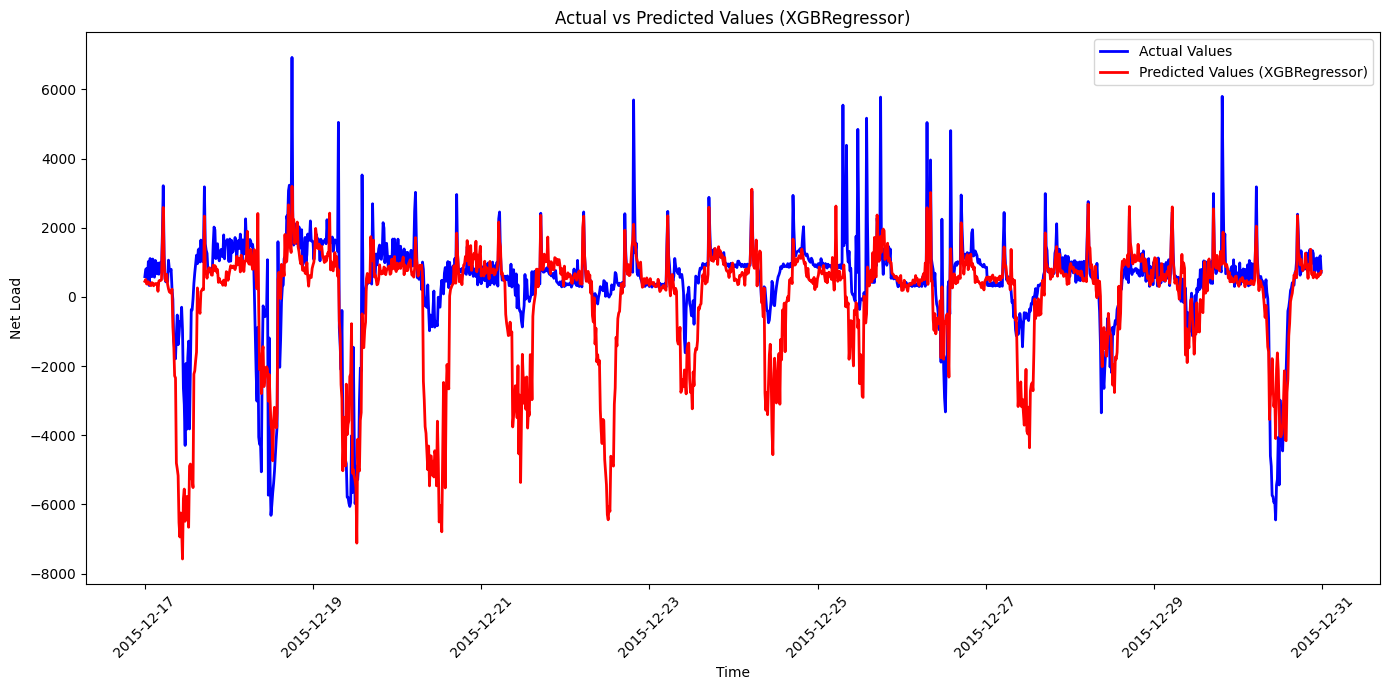

In [379]:
start_time = time.time()

def sliding_window_forecast_XGB_test(modelname, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    
    # Load the CSV file
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    XGB_best_params = {}

    # Define a mapping of parameter names to their expected types
    param_types = {
        'n_estimators': int,
        'max_depth': int,
        'learning_rate': float,
        'subsample': float,
        'colsample_bytree': float,
        'gamma': float,
        'min_child_weight':float,
    }

    # Reading the dictionary from the CSV file
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:  # Check if the key is in the mapping
                XGB_best_params[key] = param_types[key](value)  # Convert to the appropriate type
            else:
                XGB_best_params[key] = value  # Leave as is if no type mapping exists
    

    fcst = MLForecast(
        models=xgboost.XGBRegressor(
            random_state=42,
            tree_method='gpu_hist',  # Use GPU-accelerated tree construction
            predictor='gpu_predictor',  # Use GPU for prediction
            verbosity=1
        ),
        freq='15min',
        num_threads=4,
    )

    # Retrain and collect the predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)

    # Calculate the number of iterations
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps
    
    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]

        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        fcst.fit(DF_training_scaled, static_features=[])
        
        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname+"_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname+"_unscaled"])

    return final_all_preds 
 
final_all_preds_test=sliding_window_forecast_XGB_test(modelname,OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_XGB = end_time - start_time


In [380]:
# save the time spent
model_name = modelname+"_unscaled"  # The model name
file_path = os.path.join(OutputPath, "elapsed_time.csv")
file_exists = os.path.exists(file_path)

with open(file_path, mode='a', newline='') as f:
    writer = csv.writer(f)
    
    # If the file does not exist, write the header
    if not file_exists:
        writer.writerow(['Model', 'Time_Spent'])
    
    # Write the model name and the time spent value
    writer.writerow([model_name, time_spent_XGB])

print(f"Time spent for {model_name} has been saved in {file_path}.")

Time spent for XGBRegressor_unscaled has been saved in C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\outputs\elapsed_time.csv.


In [381]:
Predictions_test =final_all_preds_test[[modelname+"_unscaled"]].copy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
Predictions_test.to_csv(file_path_predictions)

### SVR

In [382]:
modelname = "SVR"

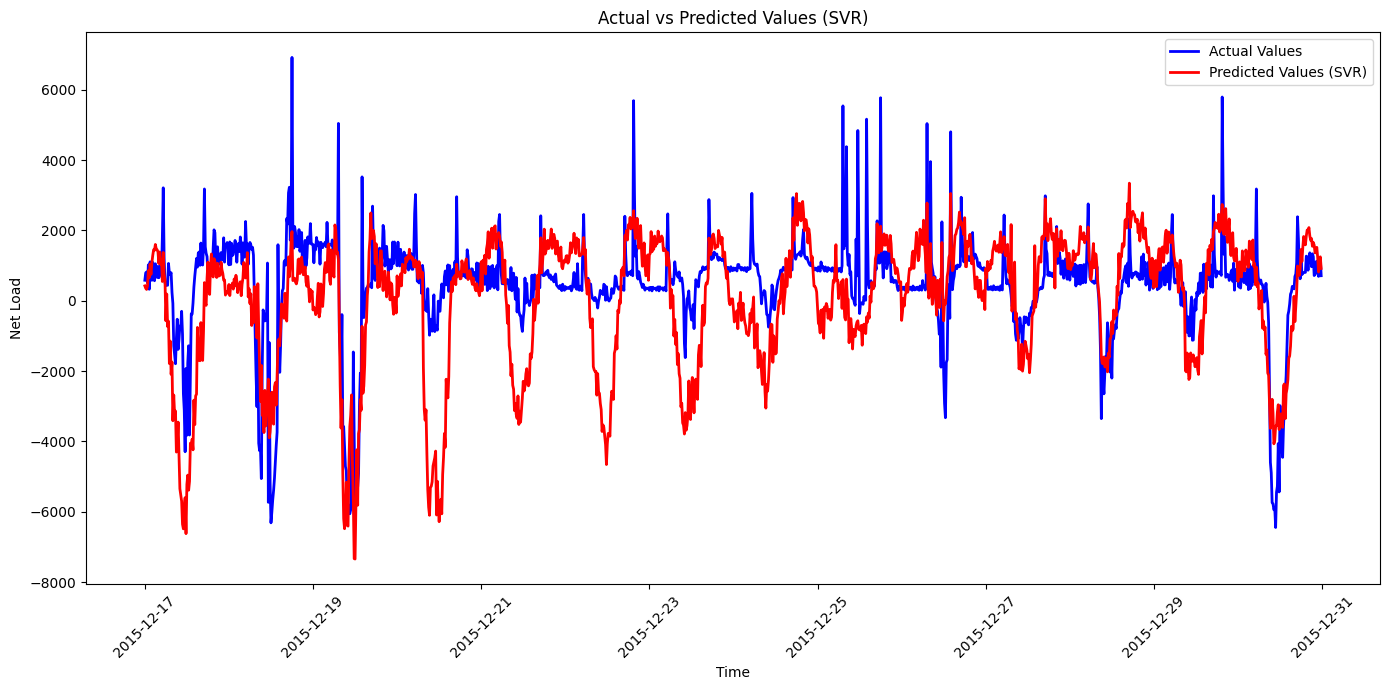

In [383]:
start_time = time.time()


def sliding_window_forecast_SVR_test(modelname, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Load the CSV file
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    SVR_best_params = {}

    # Define a mapping of parameter names to their expected types
    param_types = {
        'C': float,
        'epsilon': float,
        'gamma': str,  # Set gamma to str to allow for special values like "scale"
        'kernel': str
    }

    # Reading the dictionary from the CSV file
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:  # Check if the key is in the mapping
                if key == "gamma" and value not in ["scale", "auto"]:
                    SVR_best_params[key] = float(value)  # Convert gamma to float if it's not "scale" or "auto"
                else:
                    SVR_best_params[key] = param_types[key](value)  # Convert to the appropriate type
            else:
                SVR_best_params[key] = value  # Leave as is if no type mapping exists

    # Initialize the model using the best parameters
    fcst = MLForecast(
        models=SVR(
        ),
        freq='15min',
        num_threads=4,
    )

    # Retrain and collect the predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)

    # Calculate the number of iterations
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]

        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        fcst.fit(DF_training_scaled, static_features=[])

        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname+"_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname+"_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_SVR_test(modelname,OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_SVR = end_time - start_time

In [384]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_SVR]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)



In [385]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### Catboost

In [386]:
modelname = "CatBoostRegressor"

Learning rate set to 0.053734
0:	learn: 0.1424133	total: 13.2ms	remaining: 13.2s
100:	learn: 0.0704376	total: 1.21s	remaining: 10.8s
200:	learn: 0.0597067	total: 2.38s	remaining: 9.46s
300:	learn: 0.0519232	total: 3.58s	remaining: 8.32s
400:	learn: 0.0483903	total: 4.73s	remaining: 7.06s
500:	learn: 0.0463704	total: 5.8s	remaining: 5.77s
600:	learn: 0.0451948	total: 6.79s	remaining: 4.51s
700:	learn: 0.0443465	total: 7.75s	remaining: 3.3s
800:	learn: 0.0437269	total: 8.7s	remaining: 2.16s
900:	learn: 0.0431206	total: 9.85s	remaining: 1.08s
999:	learn: 0.0425149	total: 11.1s	remaining: 0us
Learning rate set to 0.053734
0:	learn: 0.1413007	total: 16.1ms	remaining: 16.1s
100:	learn: 0.0699778	total: 1.52s	remaining: 13.5s
200:	learn: 0.0594584	total: 3.03s	remaining: 12.1s
300:	learn: 0.0531554	total: 4.52s	remaining: 10.5s
400:	learn: 0.0492545	total: 5.68s	remaining: 8.49s
500:	learn: 0.0468318	total: 6.83s	remaining: 6.8s
600:	learn: 0.0445455	total: 7.92s	remaining: 5.26s
700:	learn: 

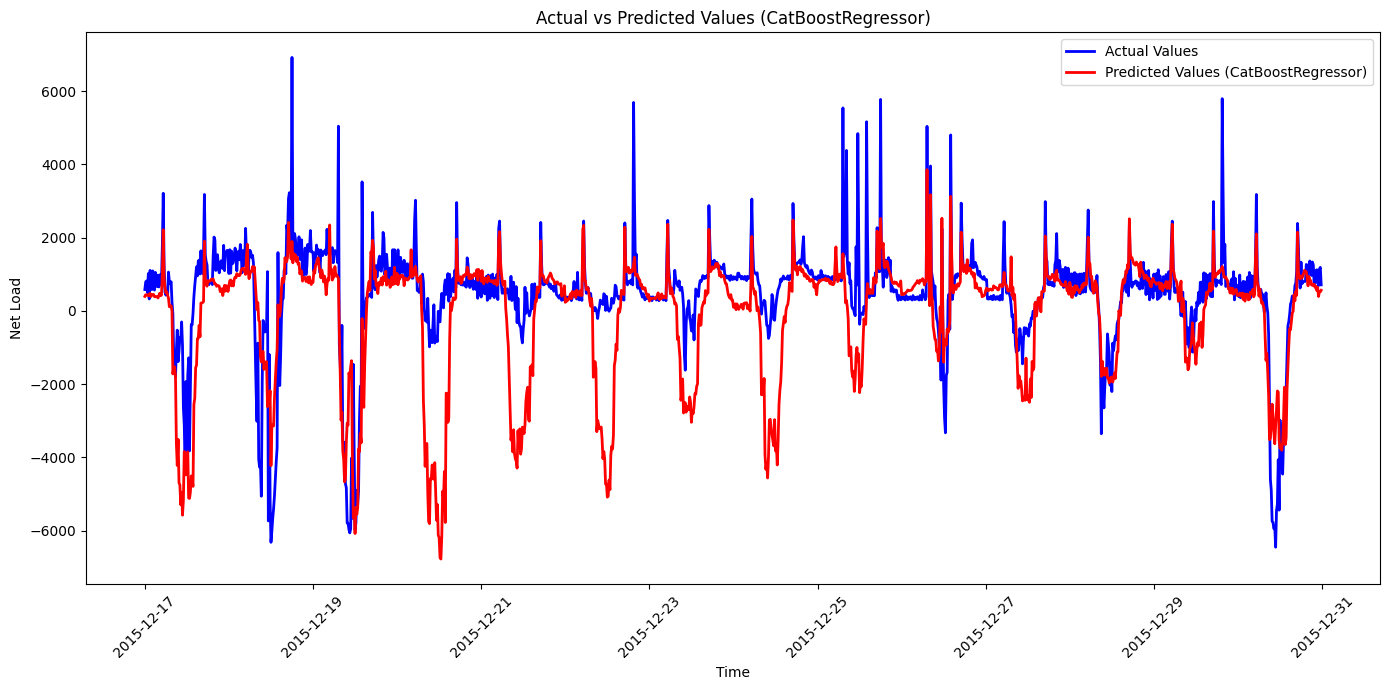

In [387]:
start_time = time.time()

def sliding_window_forecast_CatBoost_test(modelname, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Load the CSV file
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    CatBoost_best_params = {}

    # Define a mapping of parameter names to their expected types
    param_types = {
        'iterations': int,
        'depth': int,
        'learning_rate': float,
        'l2_leaf_reg': float,
        'border_count': int
    }

    # Reading the dictionary from the CSV file
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:  # Check if the key is in the mapping
                CatBoost_best_params[key] = param_types[key](value)  # Convert to the appropriate type
            else:
                CatBoost_best_params[key] = value  # Leave as is if no type mapping exists

    # Initialize the model using the best parameters
    fcst = MLForecast(
        models=CatBoostRegressor(
            random_seed=42,
            task_type="GPU",  # Use GPU if available
            verbose=100
        ),
        freq='15min',
        num_threads=4,
    )

    # Retrain and collect the predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)

    # Calculate the number of iterations
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]

        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        fcst.fit(DF_training_scaled, static_features=[])

        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname+"_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname+"_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_CatBoost_test(modelname,OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_CatBoost = end_time - start_time

In [388]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_CatBoost]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [389]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### LightGBM

In [390]:
modelname = "LGBMRegressor"

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6467
[LightGBM] [Info] Number of data points in the train set: 8832, number of used features: 36
[LightGBM] [Info] Using GPU Device: NVIDIA RTX 2000 Ada Generation, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 34 dense feature groups (0.30 MB) transferred to GPU in 0.004265 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 0.526967
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6467
[LightGBM] [Info] Number of data points in the train set: 8832, number of used features: 36
[LightGBM] [Info] Using GPU Device: NVIDIA RTX 2000 Ada Generation, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin ent

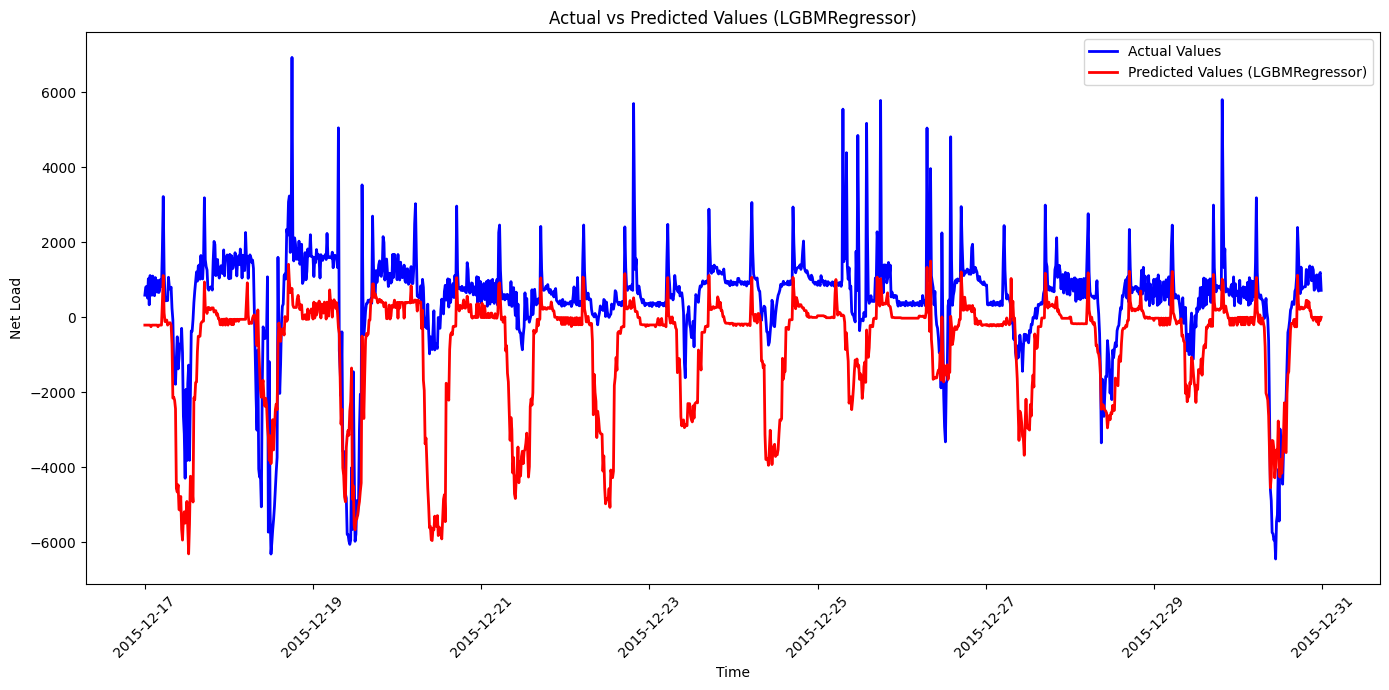

In [391]:
start_time = time.time()

def sliding_window_forecast_LightGBM_test(modelname, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Load the CSV file
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    LightGBM_best_params = {}

    # Define a mapping of parameter names to their expected types
    param_types = {
        'boosting_type': str,
        'num_leaves': int,
        'learning_rate': float,
        'n_estimators': int,
        'max_depth': int
    }

    # Reading the dictionary from the CSV file
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:  # Check if the key is in the mapping
                LightGBM_best_params[key] = param_types[key](value)  # Convert to the appropriate type
            else:
                LightGBM_best_params[key] = value  # Leave as is if no type mapping exists

    # Initialize the model using the best parameters
    fcst = MLForecast(
        models=lgb.LGBMRegressor(
            random_state=42,
            boosting_type='dart',
            device="gpu"  # Use GPU if available
        ),
        freq='15min',
        num_threads=4,
    )

    # Retrain and collect the predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)

    # Calculate the number of iterations
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]

        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        fcst.fit(DF_training_scaled, static_features=[])

        preds = fcst.predict(h=prediction_horizon_steps, X_df=DF_validation_scaled.drop(columns=["y"], axis=1))
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname+"_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname+"_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_LightGBM_test(modelname,OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_LGBM = end_time - start_time

In [392]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_LGBM]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [393]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### NHITS

In [394]:
modelname="NHITS"


Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

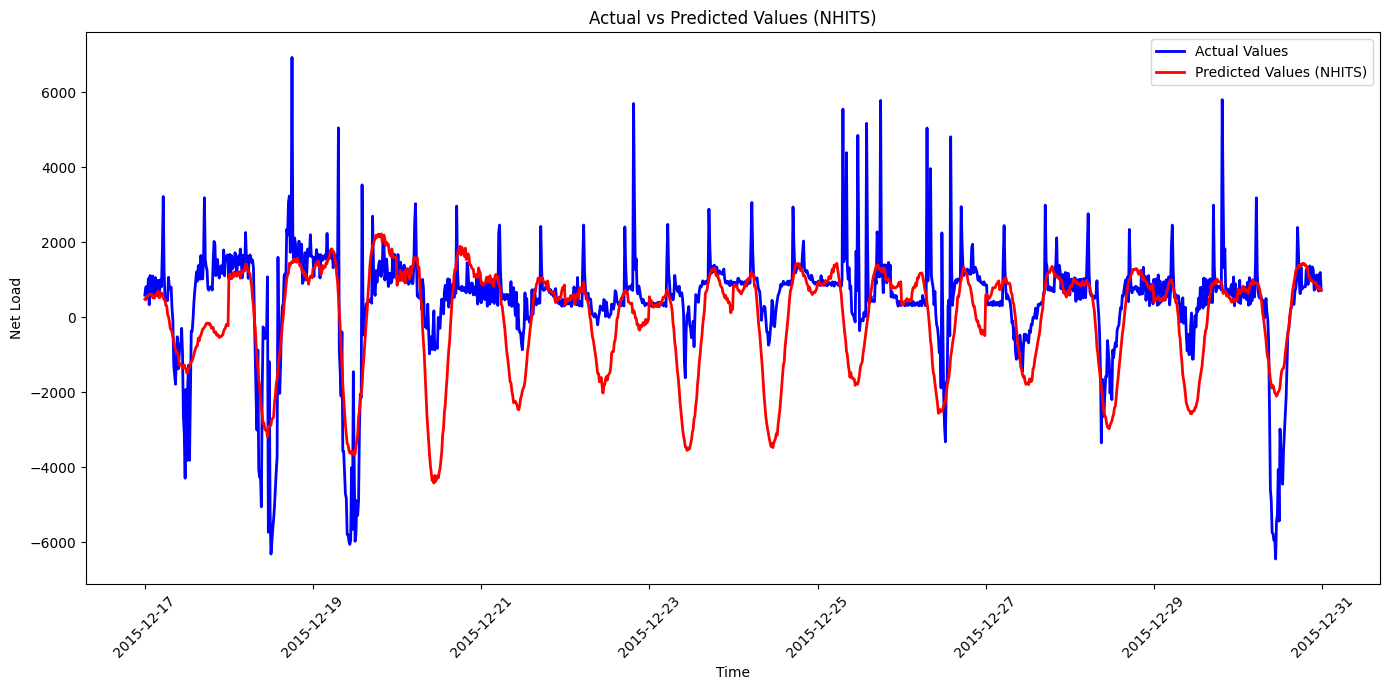

In [395]:
start_time = time.time()

def sliding_window_forecast_NHITS_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    NHITS_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'learning_rate': float,
        'num_mlp_layers': int,
        'n_stacks': int,
        'm': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                NHITS_best_params[key] = param_types[key](value)
            else:
                NHITS_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[NHITS(
            h=prediction_horizon_steps,
            input_size= prediction_horizon_steps,
            loss=MSE(),
            early_stop_patience_steps=1,
            max_steps=200,
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the model with the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_NHITS_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_NHITS = end_time - start_time

In [396]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_NHITS]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [397]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### LSTM

In [398]:
modelname = "LSTM"


Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

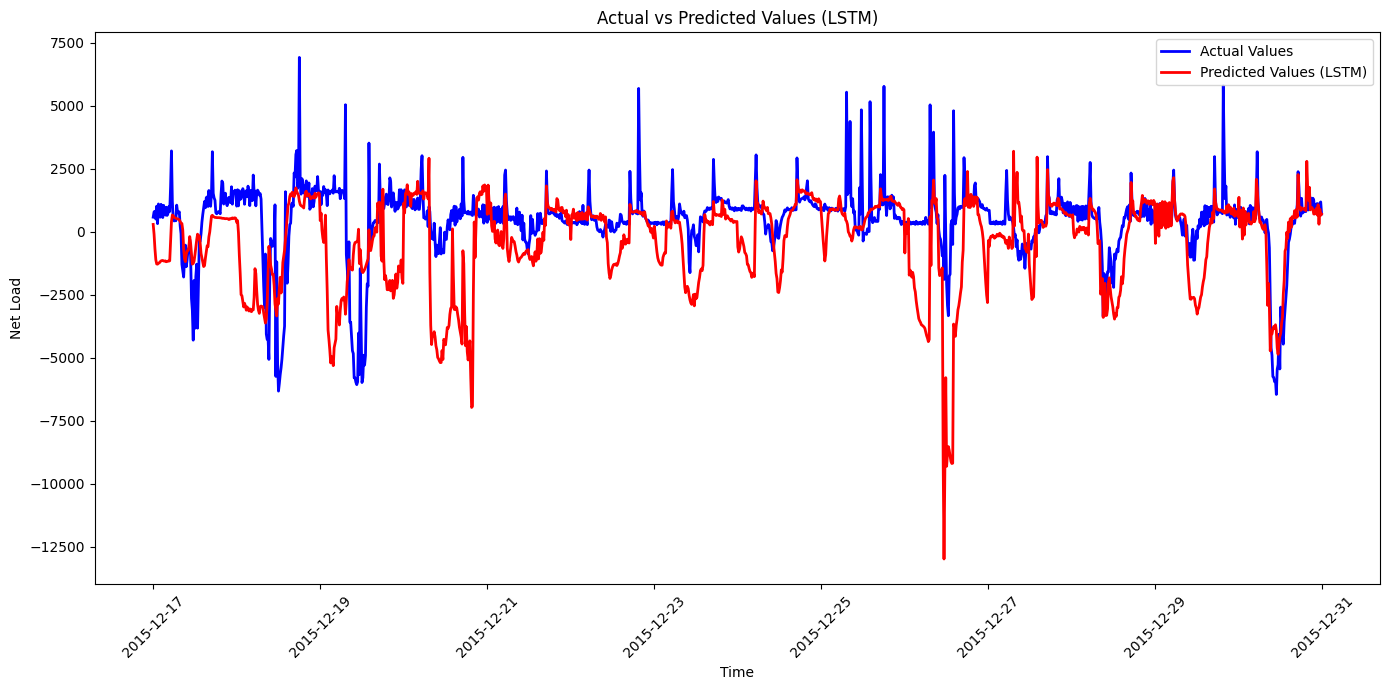

In [399]:
start_time = time.time()

def sliding_window_forecast_LSTM_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    LSTM_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'm': int,
        'encoder_n_layers': int,
        'encoder_hidden_size': int,
        'encoder_dropout': float,
        'learning_rate': float,
        'batch_size': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                LSTM_best_params[key] = param_types[key](value)
            else:
                LSTM_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[LSTM(
            h=prediction_horizon_steps,
            input_size= prediction_horizon_steps,
            loss=MSE(),
            max_steps=200,
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_LSTM_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_LSTM = end_time - start_time

In [400]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_LSTM]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [401]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### TFT

In [402]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
modelname = "TFT"


Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

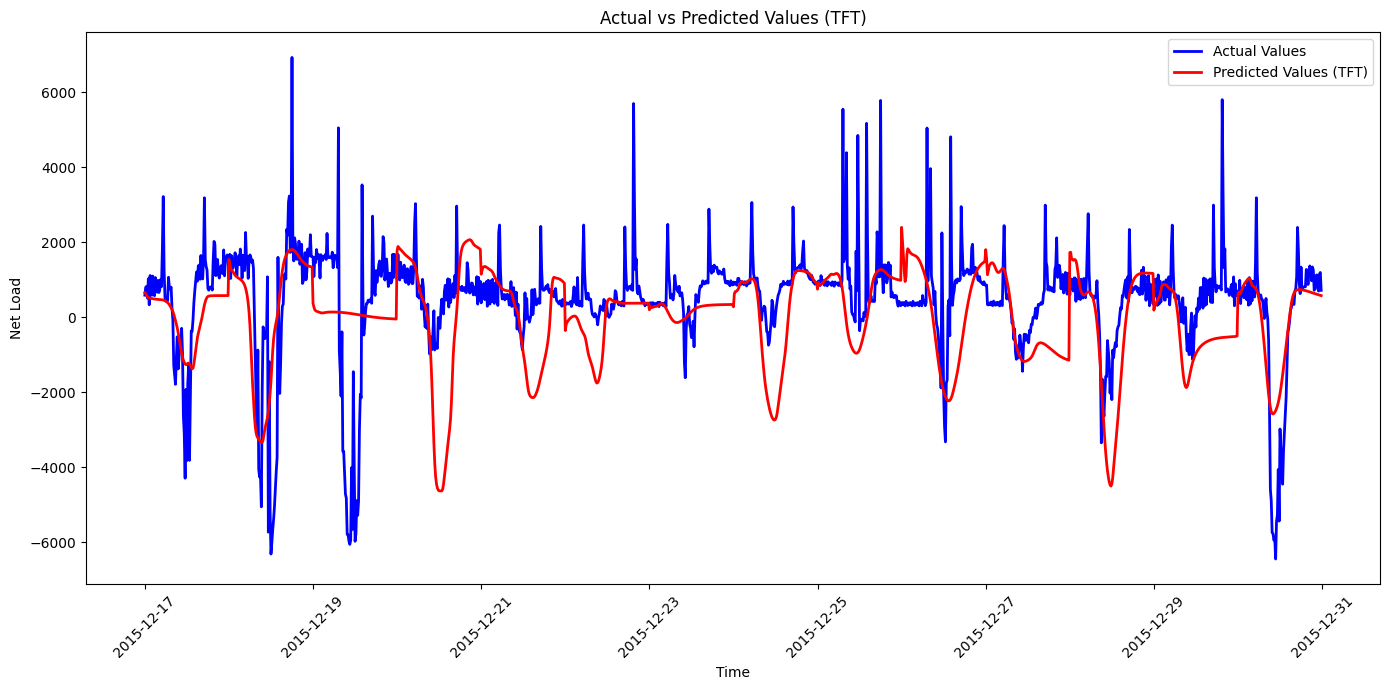

In [403]:
start_time = time.time()

def sliding_window_forecast_TFT_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    TFT_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'm': int,
        'hidden_size': int,
        'n_head': int,
        'dropout': float,
        'learning_rate': float,
        'batch_size': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                TFT_best_params[key] = param_types[key](value)
            else:
                TFT_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[TFT(
            h=prediction_horizon_steps,
            input_size=prediction_horizon_steps,
            loss=MSE(),
            max_steps=200,
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_TFT_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_TFT = end_time - start_time

In [404]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_TFT]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [405]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### TCN

In [406]:
modelname = "TCN"


In [407]:
"""start_time = time.time()

def sliding_window_forecast_TCN_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    TCN_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'm': int,
        'hidden_size': int,
        'kernel_size': int,
        'learning_rate': float,
        'batch_size': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                TCN_best_params[key] = param_types[key](value)
            else:
                TCN_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[TCN(
            h=prediction_horizon_steps,
            input_size= prediction_horizon_steps,
            loss=MSE(),
            max_steps=500,
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_TCN_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_TCN = end_time - start_time"""

'start_time = time.time()\n\ndef sliding_window_forecast_TCN_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):\n    # Split future and past features\n    future_features, past_features = separate_future_past_features(features_after_FS1)\n    past_features.remove("y")\n    mandatory_columns = ["unique_id", "ds", "y"]\n    mandatory_columns_future = ["unique_id", "ds"]\n\n    # Load the best parameters from CSV\n    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")\n    TCN_best_params = {}\n\n    # Define the parameter mapping for correct types\n    param_types = {\n        \'m\': int,\n        \'hidden_size\': int,\n        \'kernel_size\': int,\n        \'learning_rate\': float,\n        \'batch_size\': int\n    }\n\n    # Reading the parameters from CSV\n    with open(file_path, mode=\'r\') as f:\n        reader = csv.reader(f)\n        next(reader)  # Skip the header 

In [408]:
"""model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_TCN]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)"""

'model_name = modelname+"_unscaled"  # The model name\n\n# Load the existing elapsed_time.csv into a DataFrame\nfile_path = os.path.join(OutputPath, "elapsed_time.csv")\nelapsed_time_df = pd.read_csv(file_path)\n\n# Create a new row with the model name and time spent\nnew_row_df = pd.DataFrame({\'Model\': [model_name], \'Time_Spent\': [time_spent_TCN]})\n\nelapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)\n\n# Save the updated DataFrame back into the CSV file\nelapsed_time_df.to_csv(file_path, index=False)'

In [409]:
"""#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)"""

'#save the preds\nfile_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")\npredictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)\n\npredictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()\nfile_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")\npredictions_df.to_csv(file_path_predictions)'

### TiDE

In [410]:
modelname = "TiDE"


Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

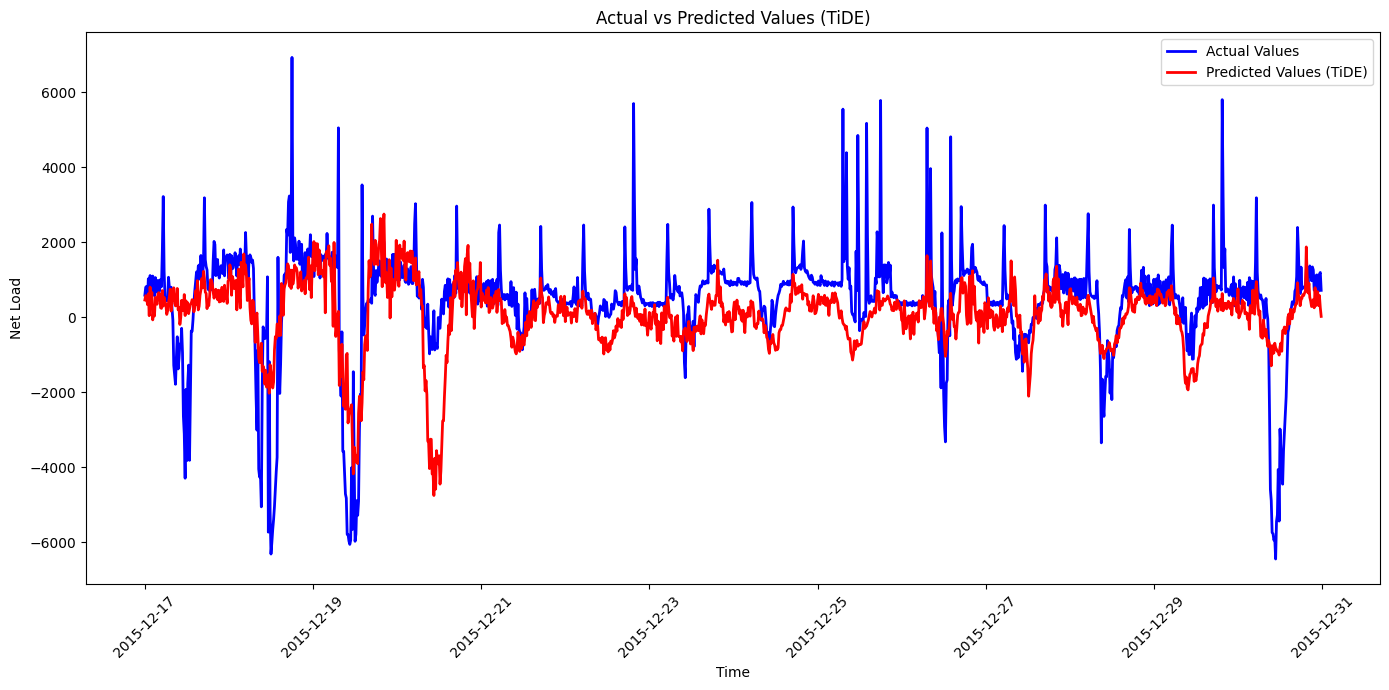

In [411]:
start_time = time.time()

def sliding_window_forecast_TiDE_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    TiDE_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'm': int,
        'hidden_size': int,
        'dropout': float,
        'learning_rate': float,
        'batch_size': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                TiDE_best_params[key] = param_types[key](value)
            else:
                TiDE_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[TiDE(
            h=prediction_horizon_steps,
            input_size= prediction_horizon_steps,
            loss=MSE(),
            max_steps=200,
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_TiDE_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)

end_time = time.time()

time_spent_TiDE = end_time - start_time

In [412]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_TiDE]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [413]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)

### KAN

In [414]:
modelname = "KAN"


Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

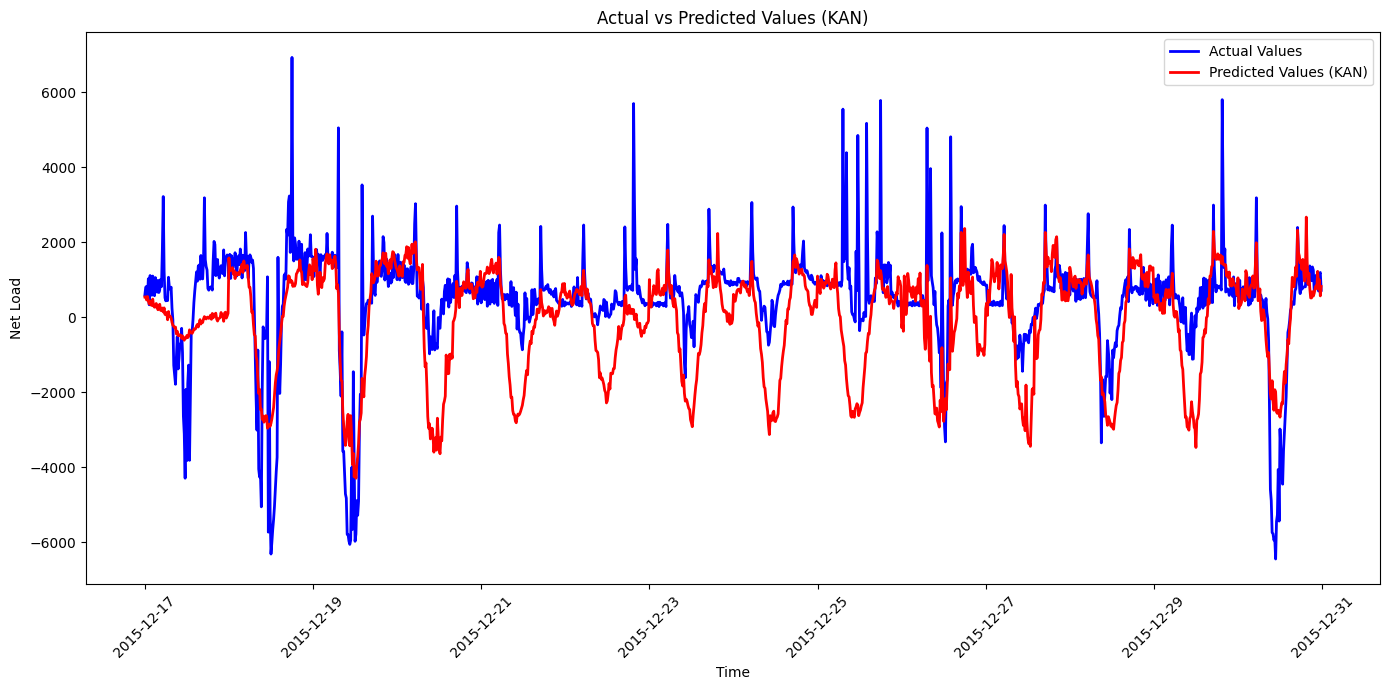

In [415]:
start_time = time.time()

def sliding_window_forecast_KAN_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=96, fixed_training_size=8832):
    # Split future and past features
    future_features, past_features = separate_future_past_features(features_after_FS1)
    past_features.remove("y")
    mandatory_columns = ["unique_id", "ds", "y"]
    mandatory_columns_future = ["unique_id", "ds"]

    # Load the best parameters from CSV
    file_path = os.path.join(OutputPath, modelname+"_params_dict.csv")
    KAN_best_params = {}

    # Define the parameter mapping for correct types
    param_types = {
        'm': int,
        'hidden_size': int,
        'grid_size': int,
        'spline_order': int,
        'n_hidden_layers': int,
        'learning_rate': float,
        'batch_size': int
    }

    # Reading the parameters from CSV
    with open(file_path, mode='r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip the header row if it exists
        for row in reader:
            key, value = row
            if key in param_types:
                KAN_best_params[key] = param_types[key](value)
            else:
                KAN_best_params[key] = value

    # Initialize the model using the best parameters
    fcst = NeuralForecast(
        models=[KAN(
            h=prediction_horizon_steps,
            input_size= prediction_horizon_steps,
            max_steps=200,
            loss=MSE(),
            devices=[0]
        )],
        freq='15min'
    )

    # Retrain and collect predictions using the best hyperparameters
    final_all_preds = pd.DataFrame()
    total_rows = len(DF_training_validation_scaled)
    num_iterations = (total_rows - fixed_training_size) // prediction_horizon_steps

    for i in range(num_iterations):
        start_train_idx = i * prediction_horizon_steps
        end_train_idx = start_train_idx + fixed_training_size

        DF_training_scaled = DF_training_validation_scaled.iloc[start_train_idx:end_train_idx]
        start_val_idx = end_train_idx
        end_val_idx = start_val_idx + prediction_horizon_steps
        DF_validation_scaled = DF_training_validation_scaled.iloc[start_val_idx:end_val_idx]

        # Fit and predict using the best hyperparameters
        fcst.fit(df=DF_training_scaled[future_features + past_features + mandatory_columns], val_size=prediction_horizon_steps)
        preds = fcst.predict(futr_df=DF_validation_scaled[future_features + mandatory_columns_future])

        # Inverse scaling and storing final predictions
        predictions_reshaped = preds[modelname].to_numpy().reshape(-1, 1)
        predictions_original_scale = scaler_target.inverse_transform(predictions_reshaped).flatten()

        preds[modelname + "_unscaled"] = predictions_original_scale
        final_all_preds = pd.concat([final_all_preds, preds], axis=0)

    final_all_preds.set_index('ds', inplace=True)
    plot_predictions(modelname, DF_test["y"], final_all_preds[modelname + "_unscaled"])

    return final_all_preds

final_all_preds_test=sliding_window_forecast_KAN_test(modelname, features_after_FS1, OutputPath, DF_training_validation_scaled, scaler_target, prediction_horizon_steps=prediction_horizon_steps, fixed_training_size=8832)


end_time = time.time()

time_spent_KAN = end_time - start_time

In [416]:
model_name = modelname+"_unscaled"  # The model name

# Load the existing elapsed_time.csv into a DataFrame
file_path = os.path.join(OutputPath, "elapsed_time.csv")
elapsed_time_df = pd.read_csv(file_path)

# Create a new row with the model name and time spent
new_row_df = pd.DataFrame({'Model': [model_name], 'Time_Spent': [time_spent_KAN]})

elapsed_time_df = pd.concat([elapsed_time_df, new_row_df], ignore_index=True)

# Save the updated DataFrame back into the CSV file
elapsed_time_df.to_csv(file_path, index=False)

In [417]:
#save the preds
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

predictions_df[modelname+"_unscaled"]=final_all_preds_test[[modelname+"_unscaled"]].to_numpy()
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
predictions_df.to_csv(file_path_predictions)
print(file_path_predictions)

C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\outputs\Predictions_test.csv


### save the test

In [418]:
# Load predictions
file_path_predictions = os.path.join(OutputPath, "Predictions_test.csv")
Preds = pd.read_csv(file_path_predictions, index_col=0, parse_dates=True)

# Keep only the overlapping timestamps
DF_test_aligned = DF_test.loc[DF_test.index.intersection(Preds.index)].copy()
Preds_aligned   = Preds.loc[Preds.index.intersection(DF_test.index)].copy()

# Make sure both are in the same order
DF_test_aligned = DF_test_aligned.sort_index()
Preds_aligned   = Preds_aligned.sort_index()

# Add actuals
Preds_aligned["y"] = DF_test_aligned["y"]

y_true = Preds_aligned["y"]

models = [
    "XGBRegressor_unscaled",
    "SVR_unscaled",
    "CatBoostRegressor_unscaled",
    "LGBMRegressor_unscaled",
    "NHITS_unscaled",
    "LSTM_unscaled",
    "TFT_unscaled",
#    "TCN_unscaled",
    "TiDE_unscaled",
    "KAN_unscaled"
]

errors_list = []
for model in models:
    y_pred = Preds_aligned[model].values
    errors = ErrorCalculator(model, y_true.values, y_pred)
    errors_list.append(errors)

errors_df_test = pd.DataFrame(errors_list)



In [419]:
errors_df_test

,Pipelines,RMSE,MAE,MSE,PMAE,PMSE,PRMSE,VMAE,VMSE,VRMSE,xMAE,xMSE,xRMSE
0,XGBRegressor_unscaled,1526.356028,911.961353,2.329763e+06,1575.073678,4.811795e+06,2193.580302,1781.966535,4.246477e+06,2060.698083,1690.365118,4.496770e+06,2120.558897
1,SVR_unscaled,1596.245496,1197.959414,2.548000e+06,1856.635729,5.386720e+06,2320.930920,1642.240277,3.589852e+06,1894.690568,1737.163454,4.385412e+06,2094.137584
2,CatBoostRegressor_unscaled,1494.921474,903.917603,2.234790e+06,1535.044537,4.492881e+06,2119.641646,1786.090687,4.617169e+06,2148.759943,1674.940483,4.562141e+06,2135.916843
3,LGBMRegressor_unscaled,1754.563106,1358.024306,3.078492e+06,2556.186994,8.465588e+06,2909.568336,1535.503191,3.297862e+06,1816.001696,1987.408997,5.585863e+06,2363.443011
4,NHITS_unscaled,1382.604664,935.007343,1.911596e+06,2461.027200,8.985691e+06,2997.614163,2030.363554,5.211397e+06,2282.848409,2221.039061,6.882458e+06,2623.443965
5,LSTM_unscaled,2083.339663,1368.239885,4.340304e+06,2539.242820,1.186326e+07,3444.307721,2544.092547,9.113304e+06,3018.824986,2541.945339,1.033084e+07,3214.162413
6,TFT_unscaled,1551.694280,1074.363552,2.407755e+06,2687.905690,9.779725e+06,3127.255123,3040.164419,1.209371e+07,3477.601795,2884.202539,1.106920e+07,3327.040689
7,TiDE_unscaled,1268.955072,868.669532,1.610247e+06,2417.709847,8.171944e+06,2858.661229,2933.683919,1.030587e+07,3210.275166,2705.237383,9.361076e+06,3059.587631
8,KAN_unscaled,1372.877840,975.720470,1.884794e+06,2226.625906,8.329572e+06,2886.099812,1951.437115,5.025230e+06,2241.702393,2073.276427,6.488221e+06,2547.198649


In [420]:
def highlight_min(s):
    is_min = s == s.min()
    return ['font-weight: bold' if v else '' for v in is_min]

# Select only numeric columns (avoid 'Pipelines')
numeric_cols = errors_df_test.select_dtypes(include=['number']).columns

styled_df = errors_df_test.style.apply(highlight_min, subset=numeric_cols)

styled_df

,Pipelines,RMSE,MAE,MSE,PMAE,PMSE,PRMSE,VMAE,VMSE,VRMSE,xMAE,xMSE,xRMSE
0,XGBRegressor_unscaled,1526.356028,911.961353,2329762.725369,1575.073678,4811794.541908,2193.580302,1781.966535,4246476.591321,2060.698083,1690.365118,4496770.035092,2120.558897
1,SVR_unscaled,1596.245496,1197.959414,2547999.683684,1856.635729,5386720.337175,2320.930920,1642.240277,3589852.349854,1894.690568,1737.163454,4385412.222103,2094.137584
2,CatBoostRegressor_unscaled,1494.921474,903.917603,2234790.212913,1535.044537,4492880.707378,2119.641646,1786.090687,4617169.292684,2148.759943,1674.940483,4562140.758732,2135.916843
3,LGBMRegressor_unscaled,1754.563106,1358.024306,3078491.693288,2556.186994,8465587.900511,2909.568336,1535.503191,3297862.158088,1816.001696,1987.408997,5585862.868473,2363.443011
4,NHITS_unscaled,1382.604664,935.007343,1911595.656275,2461.027200,8985690.670495,2997.614163,2030.363554,5211396.857048,2282.848409,2221.039061,6882458.240101,2623.443965
5,LSTM_unscaled,2083.339663,1368.239885,4340304.153322,2539.242820,11863255.675149,3444.307721,2544.092547,9113304.293594,3018.824986,2541.945339,10330840.019779,3214.162413
6,TFT_unscaled,1551.694280,1074.363552,2407755.139712,2687.905690,9779724.603968,3127.255123,3040.164419,12093714.245201,3477.601795,2884.202539,11069199.747556,3327.040689
7,TiDE_unscaled,1268.955072,868.669532,1610246.975470,2417.709847,8171944.020481,2858.661229,2933.683919,10305866.641222,3210.275166,2705.237383,9361076.473261,3059.587631
8,KAN_unscaled,1372.877840,975.720470,1884793.564534,2226.625906,8329572.124469,2886.099812,1951.437115,5025229.616745,2241.702393,2073.276427,6488220.956043,2547.198649


In [422]:
file_path_predictions = os.path.join(OutputPath, "Error_Results_Forecasting_test.csv")
errors_df_test.to_csv(file_path_predictions)

In [424]:
file_path_predictions = os.path.join(OutputPath, "Predictions_test_with_actuals.csv")
Preds_aligned.to_csv(file_path_predictions, index=True)

In [423]:
Preds_aligned

,XGBRegressor_unscaled,SVR_unscaled,CatBoostRegressor_unscaled,LGBMRegressor_unscaled,NHITS_unscaled,LSTM_unscaled,TFT_unscaled,TiDE_unscaled,KAN_unscaled,y
2015-12-17 00:00:00,448.91860,424.190547,398.731323,-213.348485,479.66104,297.039400,651.71655,456.40390,536.56100,584.843970
2015-12-17 00:15:00,501.89490,355.510821,443.738725,-213.348485,459.38530,-90.509575,629.16490,571.61475,538.36896,795.656573
2015-12-17 00:30:00,375.79830,322.944417,442.334258,-213.348485,551.36110,-666.545350,581.77106,546.44920,456.34772,820.174814
2015-12-17 00:45:00,367.82950,419.300367,429.321505,-213.348485,544.88990,-1100.599400,543.77637,332.42386,549.04840,508.018524
2015-12-17 01:00:00,438.88852,856.677399,413.856240,-213.348485,589.38250,-1271.398600,522.74910,619.68005,423.13968,1021.640765
...,...,...,...,...,...,...,...,...,...,...
2015-12-30 22:45:00,667.74720,1230.715030,644.301065,-5.311825,772.28595,1079.612500,601.28510,678.22034,1220.06160,806.483673
2015-12-30 23:00:00,594.24190,818.632677,396.004274,-204.914764,826.95140,305.065340,593.79150,307.95000,749.10345,694.377304
2015-12-30 23:15:00,669.50916,1092.579585,532.546110,-5.311825,730.33264,903.537600,586.41766,572.72090,993.99286,1141.953873
2015-12-30 23:30:00,643.15826,1250.598568,523.497858,-86.601559,771.42114,657.756700,579.16080,247.57965,565.65010,1189.757622


# end